# MindBridge — Problem Understanding
### Step 1: Defining the Problem Space

> **Goal:** Classify mental health status from social media text using Natural Language Processing and Machine Learning.

---

| Property | Detail |
|----------|--------|
| **Task Type** | Multi-class Text Classification |
| **Input** | Raw social media text (Reddit posts, tweets) |
| **Output** | One of 7 mental health status labels |
| **Approach** | NLP Preprocessing → TF-IDF → Classical ML Models |
| **Dataset** | ~53,000 labeled samples (Kaggle) |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("darkgrid")

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [3]:
df = pd.read_csv('/Users/vaibhav2040/Desktop/MIND_BRIDGE/data/Combined Data.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.columns = ['statement', 'status']
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df = df.reset_index(drop=True)

print("MINDBRIDGE — DATASET OVERVIEW")
print()
print(f"  Total Samples     : {len(df):,}")
print(f"  Total Features    : {df.shape[1]}")
print(f"  Missing Values    : {df.isnull().sum().sum()}")
print(f"  Duplicate Rows    : {df.duplicated().sum():,}")
print(f"  Unique Classes    : {df['status'].nunique()}")
print()
print(f"Output Classes ({df['status'].nunique()} total):\n")
for i, cls in enumerate(sorted(df['status'].unique()), 1):
    count = df['status'].value_counts()[cls]
    pct = count / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"   {i}. {cls:<25} {bar} {pct:.1f}%")


MINDBRIDGE — DATASET OVERVIEW

  Total Samples     : 51,093
  Total Features    : 2
  Missing Values    : 0
  Duplicate Rows    : 0
  Unique Classes    : 7

Output Classes (7 total):

   1. Anxiety                   ███ 7.1%
   2. Bipolar                   ██ 4.9%
   3. Depression                ██████████████ 29.5%
   4. Normal                    ███████████████ 31.4%
   5. Personality disorder       1.8%
   6. Stress                    ██ 4.5%
   7. Suicidal                  ██████████ 20.8%


In [4]:
html = """
<div style="
    background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
    border-radius: 16px;
    padding: 30px 40px;
    font-family: 'Segoe UI', sans-serif;
    color: white;
    margin: 10px 0;
    border-left: 6px solid #6C63FF;
">
    <h2 style="color:#6C63FF; margin-bottom:6px;">MindBridge — Problem Statement</h2>
    <p style="color:#aaa; font-size:13px; margin-bottom:20px;">NLP Text Classification Project</p>
    <table style="width:100%; border-collapse:collapse;">
        <tr>
            <td style="padding:10px 16px; background:rgba(108,99,255,0.15); border-radius:8px; width:50%; vertical-align:top;">
                <b style="color:#48CAE4;">Objective</b><br/>
                <span style="font-size:14px;">Automatically classify social media text into one of 7 mental health status categories using NLP and Machine Learning.</span>
            </td>
            <td style="width:2%;"></td>
            <td style="padding:10px 16px; background:rgba(72,202,228,0.1); border-radius:8px; width:48%; vertical-align:top;">
                <b style="color:#48CAE4;">Motivation</b><br/>
                <span style="font-size:14px;">Mental health crises often manifest in language before clinical detection. NLP enables scalable early-warning systems.</span>
            </td>
        </tr>
    </table>
    <br/>
    <table style="width:100%; border-collapse:collapse;">
        <tr>
            <td style="padding:10px 16px; background:rgba(255,255,255,0.05); border-radius:8px; width:23%; text-align:center;">
                <div style="color:#6C63FF; font-weight:bold; font-size:15px;">Input</div>
                <div style="font-size:13px; color:#ccc;">Raw social media text</div>
            </td>
            <td style="text-align:center; font-size:20px; color:#6C63FF;">→</td>
            <td style="padding:10px 16px; background:rgba(255,255,255,0.05); border-radius:8px; width:23%; text-align:center;">
                <div style="color:#6C63FF; font-weight:bold; font-size:15px;">Process</div>
                <div style="font-size:13px; color:#ccc;">NLP + TF-IDF + ML</div>
            </td>
            <td style="text-align:center; font-size:20px; color:#6C63FF;">→</td>
            <td style="padding:10px 16px; background:rgba(255,255,255,0.05); border-radius:8px; width:23%; text-align:center;">
                <div style="color:#6C63FF; font-weight:bold; font-size:15px;">Output</div>
                <div style="font-size:13px; color:#ccc;">7 mental health labels</div>
            </td>
            <td style="text-align:center; font-size:20px; color:#6C63FF;">→</td>
            <td style="padding:10px 16px; background:rgba(255,255,255,0.05); border-radius:8px; width:23%; text-align:center;">
                <div style="color:#6C63FF; font-weight:bold; font-size:15px;">Impact</div>
                <div style="font-size:13px; color:#ccc;">Early mental health detection</div>
            </td>
        </tr>
    </table>
    <br/>
    <p style="color:#aaa; font-size:12px; margin:0;">
        Dataset: ~53,000 samples &nbsp;|&nbsp;
        Classes: 7 &nbsp;|&nbsp;
        Models: Logistic Regression, Naive Bayes, Random Forest, SVM &nbsp;|&nbsp;
        Metric: F1 Score (Macro)
    </p>
</div>
"""
display(HTML(html))

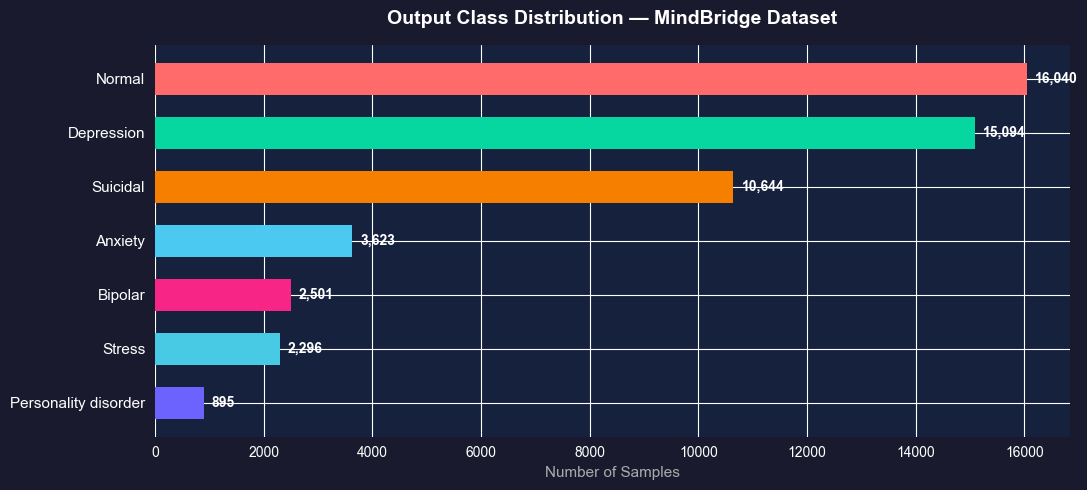

Plot saved to results/plots/


In [5]:
class_counts = df['status'].value_counts().sort_values(ascending=True)
colors = ['#6C63FF','#48CAE4','#f72585','#4cc9f0','#f77f00','#06d6a0','#ff6b6b']

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

bars = ax.barh(class_counts.index, class_counts.values,
               color=colors, height=0.6, edgecolor='none')

for bar, val in zip(bars, class_counts.values):
    ax.text(val + 150, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', ha='left',
            color='white', fontsize=10, fontweight='bold')

ax.set_xlabel('Number of Samples', color='#aaa', fontsize=11)
ax.set_title('Output Class Distribution — MindBridge Dataset',
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='white')
ax.spines[['top','right','bottom','left']].set_visible(False)
for label in ax.get_yticklabels():
    label.set_color('white')
    label.set_fontsize(11)

plt.tight_layout()
plt.savefig('/Users/vaibhav2040/Desktop/MIND_BRIDGE/results/plots/00_class_distribution_preview.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Plot saved to results/plots/")

In [9]:
df['word_count'] = df['statement'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['statement'].apply(lambda x: len(str(x)))

stats = df.groupby('status')[['word_count', 'char_count']].describe().round(2)

html_rows = ""
for cls in sorted(df['status'].unique()):
    wc = df[df['status'] == cls]['word_count']
    cc = df[df['status'] == cls]['char_count']
    html_rows += f"""
    <tr>
        <td style="padding:10px 16px; color:#48CAE4; font-weight:bold;">{cls}</td>
        <td style="padding:10px 16px; text-align:center;">{wc.mean():.1f}</td>
        <td style="padding:10px 16px; text-align:center;">{wc.min():.0f}</td>
        <td style="padding:10px 16px; text-align:center;">{wc.max():.0f}</td>
        <td style="padding:10px 16px; text-align:center;">{wc.std():.1f}</td>
        <td style="padding:10px 16px; text-align:center;">{cc.mean():.1f}</td>
        <td style="padding:10px 16px; text-align:center;">{cc.max():.0f}</td>
    </tr>
    """

html = f"""
<div style="
    background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
    border-radius: 16px;
    padding: 28px 36px;
    font-family: 'Segoe UI', sans-serif;
    color: white;
    border-left: 6px solid #6C63FF;
    margin: 10px 0;
">
    <h2 style="color:#6C63FF; margin-bottom:4px;">Text Statistics by Class</h2>
    <p style="color:#aaa; font-size:13px; margin-bottom:20px;">Summary of word and character counts per mental health category</p>
    <table style="width:100%; border-collapse:collapse;">
        <thead>
            <tr style="border-bottom: 1px solid rgba(108,99,255,0.4);">
                <th style="padding:10px 16px; text-align:left; color:#6C63FF;">Class</th>
                <th style="padding:10px 16px; text-align:center; color:#6C63FF;">Avg Words</th>
                <th style="padding:10px 16px; text-align:center; color:#6C63FF;">Min Words</th>
                <th style="padding:10px 16px; text-align:center; color:#6C63FF;">Max Words</th>
                <th style="padding:10px 16px; text-align:center; color:#6C63FF;">Std Words</th>
                <th style="padding:10px 16px; text-align:center; color:#6C63FF;">Avg Chars</th>
                <th style="padding:10px 16px; text-align:center; color:#6C63FF;">Max Chars</th>
            </tr>
        </thead>
        <tbody>
            {html_rows}
        </tbody>
    </table>
</div>
"""
display(HTML(html))
print("Summary statistics by class computed successfully.")

Class,Avg Words,Min Words,Max Words,Std Words,Avg Chars,Max Chars
Anxiety,143.1,1,1592,152.1,761.2,8539
Bipolar,178.3,4,4804,180.9,958.1,26163
Depression,168.2,1,4239,188.4,844.8,19822
Normal,17.4,1,255,22.8,91.2,1358
Personality disorder,177.9,5,5419,233.1,949.5,27588
Stress,111.7,1,1606,101.1,594.0,8389
Suicidal,146.5,1,6300,187.0,735.4,32759


Summary statistics by class computed successfully.


## Step 1 Complete — Key Takeaways

| Finding | Detail |
|---------|--------|
| **Dataset Size** | ~53,000 samples after cleaning |
| **Classes** | 7 distinct mental health states confirmed |
| **Task** | Multi-class NLP classification |
| **Key Challenge** | Class imbalance — will handle in preprocessing |
| **Success Metric** | Macro F1 Score (accounts for imbalance) |

### Next Step: 02_Preprocessing.ipynb
- Clean text (lowercase, punctuation, stopwords, lemmatization)
- Convert text to numbers via TF-IDF